In [1]:
import numpy as np
import scipy.stats as stats
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
# from dynamic_routing_analysis import decoding_utils
# from dynamic_routing_analysis import plot_utils
# from dynamic_routing_analysis import spike_utils

import os
# import pingouin as pg

import matplotlib
import matplotlib.font_manager as fm

matplotlib.rcParams['font.size'] = 8
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
fm.FontProperties().set_family('arial')

%load_ext autoreload
%autoreload 2
%matplotlib inline
# %matplotlib widget

In [2]:
# results_path = r"s3://aind-scratch-data/dynamic-routing/decoding/results/cross_temporal_decode_context_all_units_0/" #context module only
# results_path = r"s3://aind-scratch-data/dynamic-routing/decoding/results/cross_temporal_decode_context_all_units_500ms_bins_0/"

# results_path = r"s3://aind-scratch-data/dynamic-routing/decoding/results/cross_temporal_decode_context_all_units_vis_target_0/"
# results_path = r"s3://aind-scratch-data/dynamic-routing/decoding/results/cross_temporal_decode_context_all_units_aud_target_0/"

# results_path = r"s3://aind-scratch-data/dynamic-routing/decoding/results/cross_temporal_decode_context_all_units_all_areas_0/" #all units, all areas
results_path = r"s3://aind-scratch-data/dynamic-routing/decoding/results/cross_temporal_decode_context_all_units_all_areas_1/" #all units, all areas

# results_path = r"s3://aind-scratch-data/dynamic-routing/decoding/results/cross_temporal_decode_context_all_units_PL_0/"

# results_path = r"s3://aind-scratch-data/dynamic-routing/decoding/results/cross_temporal_decode_context_all_units_all_areas_20260910_234254/"

In [3]:
session_table_path=r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CO decoding results\session_table_v0.289.parquet"


session_table=pl.read_parquet(session_table_path)

dr_session_list=(
    session_table.filter(
    pl.col('project')=="DynamicRouting",
    # pl.col('project')=="Templeton",
    pl.col('is_production'),
    pl.col('is_annotated'),
    pl.col('issues')==[],
    pl.col('is_opto_perturbation').eq(False),
    pl.col('is_injection_perturbation').eq(False),
    pl.col('is_context_naive').eq(False),
    # pl.col('is_good_behavior').eq(True),
    # pl.col('is_engaged').eq(True),
    )['session_id'].to_list()
    )

block_dprime_threshold=1.0

good_behavior_table={
    'session_id':[],
    'n_good_vis_blocks':[],
    'n_good_aud_blocks':[],
    'n_engaged_blocks':[],
}

for sel_session in dr_session_list:
    n_good_vis_blocks=np.sum(session_table.filter(pl.col('session_id') == sel_session)['cross_modality_dprime_vis_blocks'].to_numpy()[0]>=block_dprime_threshold)
    n_good_aud_blocks=np.sum(session_table.filter(pl.col('session_id') == sel_session)['cross_modality_dprime_aud_blocks'].to_numpy()[0]>=block_dprime_threshold)
    good_behavior_table['session_id'].append(sel_session)
    good_behavior_table['n_good_vis_blocks'].append(n_good_vis_blocks)
    good_behavior_table['n_good_aud_blocks'].append(n_good_aud_blocks)
    n_engaged_blocks=np.sum(session_table.filter(pl.col('session_id') == sel_session)['n_contingent_rewards'].to_numpy()[0]>=10)
    good_behavior_table['n_engaged_blocks'].append(n_engaged_blocks)

good_behavior_table=pd.DataFrame(good_behavior_table)
dr_session_list=good_behavior_table.query('n_good_vis_blocks>=2 and n_good_aud_blocks>=2 and n_engaged_blocks>=4')['session_id'].values

In [ ]:
#to save memory loop through each session individually, then save output

savepath=r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CO decoding results\cross_temporal_decoding_2026-09-10"


for sel_session in dr_session_list:

    cross_temporal_decoding_results = {
        'session_id': [],
        'structure': [],
        'bin_centers': [],
        'n_timebins': [],
        'cross_temporal_matrix': []
    }

    results = (
        pl.scan_parquet(results_path)
        .filter(
            # pl.col('structure').eq(sel_structure),
            pl.col('time_aligned_to').eq('stim_start_time'),
            pl.col('session_id').eq(sel_session)
        )
        .with_columns(
            pl.col('bin_center').round(decimals=3),
            pl.col('train_bin_center').round(decimals=3),
            pl.col('test_bin_center').round(decimals=3)
        )
        .sort('bin_center','train_bin_center','test_bin_center')
        .collect()
    )

    if results.shape[0] == 0:
        print(f"No results for session: {sel_session}")
        continue
    
    #find how many timebins there are
    timebins = results.filter(pl.col('is_cross_temporal') == False).select(pl.col('bin_center')).unique()
    n_timebins = timebins.shape[0]

    #loop through each structure
    for structure in results.select(pl.col('structure')).unique()['structure']:
        structure_results = results.filter(pl.col('structure').eq(structure))
        
        #make a matrix to store the cross-temporal results
        cross_temporal_matrix = np.full((n_timebins, n_timebins), np.nan)

        #first get non-cross temporal decoding for each timebin, average across repeats, and add to matrix
        non_cross_temporal_results = results.filter(pl.col('is_cross_temporal') == False)
        for i, timebin in enumerate(timebins['bin_center']):
            mean_result = non_cross_temporal_results.filter(
                (pl.col('bin_center') == timebin) &
                (pl.col('time_aligned_to').eq('stim_start_time'))
            ).select(pl.col('balanced_accuracy_test')).to_numpy().mean()
            cross_temporal_matrix[i, i] = mean_result

        #then get cross temporal decoding for each train-test bin combination, average across repeats, and fill in matrix 
        cross_temporal_results = results.filter(pl.col('is_cross_temporal') == True)
        for i, train_timebin in enumerate(timebins['bin_center']):
            for j, test_timebin in enumerate(timebins['bin_center']):
                if i==j:
                    continue
                mean_result = cross_temporal_results.filter(
                    (pl.col('train_bin_center') == train_timebin) & 
                    (pl.col('test_bin_center') == test_timebin) &
                    (pl.col('train_time_aligned_to').eq('stim_start_time')) &
                    (pl.col('test_time_aligned_to').eq('stim_start_time'))
                ).select(pl.col('balanced_accuracy_test')).to_numpy().mean()
                cross_temporal_matrix[i, j] = mean_result
        if len(cross_temporal_results) > 0:
            cross_temporal_decoding_results['session_id'].append(sel_session)
            cross_temporal_decoding_results['structure'].append(structure)
            cross_temporal_decoding_results['bin_centers'].append(timebins['bin_center'].to_numpy())
            cross_temporal_decoding_results['n_timebins'].append(n_timebins)
            cross_temporal_decoding_results['cross_temporal_matrix'].append(list(cross_temporal_matrix))

    cross_temporal_decoding_results=pd.DataFrame(cross_temporal_decoding_results)
    cross_temporal_decoding_results.to_parquet(f"{savepath}\\cross_temporal_decoding_results_{sel_session}.parquet")

    print(f"Finished processing session: {sel_session}")

Finished processing session: 626791_2022-08-15
Finished processing session: 644864_2023-01-30
Finished processing session: 644864_2023-01-31
Finished processing session: 644864_2023-02-02
No results for session: 644866_2023-02-07
Finished processing session: 644866_2023-02-08
Finished processing session: 644866_2023-02-09
Finished processing session: 644866_2023-02-10
Finished processing session: 649943_2023-02-13
Finished processing session: 649943_2023-02-14
Finished processing session: 649943_2023-02-15
Finished processing session: 649943_2023-02-16
Finished processing session: 644867_2023-02-20
Finished processing session: 644867_2023-02-22
Finished processing session: 644867_2023-02-23
Finished processing session: 660023_2023-08-09
Finished processing session: 666986_2023-08-15
Finished processing session: 666986_2023-08-17
Finished processing session: 662892_2023-08-22
Finished processing session: 662892_2023-08-23
Finished processing session: 662892_2023-08-24
Finished processin

In [48]:
# cross_temporal_decoding_results

In [ ]:
# np.vstack(list(cross_temporal_matrix))

array([[0.5744514 , 0.5736016 , 0.57232963, ..., 0.57063406, 0.57697425,
        0.5795085 ],
       [0.56751421, 0.55887697, 0.56680935, ..., 0.57443011, 0.56850986,
        0.57570478],
       [0.57097662, 0.57170212, 0.57550184, ..., 0.57006257, 0.57298638,
        0.57717883],
       ...,
       [0.56878027, 0.56954413, 0.56084728, ..., 0.57123633, 0.56639166,
        0.57595233],
       [0.57264697, 0.56424143, 0.57427662, ..., 0.57564991, 0.58038507,
        0.57122659],
       [0.57431785, 0.56624819, 0.57501803, ..., 0.57241485, 0.58054776,
        0.56944658]])

In [18]:
consolidated_results = (
    pl.scan_parquet(savepath+"\\")
).collect()

In [42]:
# consolidated_results['structure'].unique().to_list()

In [49]:
sel_structure='context_module'

# consolidated_results.filter(pl.col('structure').eq(sel_structure))['cross_temporal_matrix']

structure_mean_results=(
    consolidated_results.filter(pl.col('structure').eq(sel_structure))
).to_pandas()

cross_temporal_df = pd.DataFrame({
    'session_id': structure_mean_results['session_id'],
    'cross_temporal_matrix': structure_mean_results['cross_temporal_matrix']
})
cross_temporal_df['length']=cross_temporal_df['cross_temporal_matrix'].apply(len)

mean_cross_temporal_matrix=np.nanmean(np.dstack(cross_temporal_df['cross_temporal_matrix'].apply(np.vstack).values), axis=2)


In [45]:
# # get the mean across sessions

# cross_temporal_df = pd.DataFrame({
#     'session_id': cross_temporal_decoding_results['session_id'],
#     'cross_temporal_matrix': cross_temporal_decoding_results['cross_temporal_matrix']
# })
# cross_temporal_df['length']=cross_temporal_df['cross_temporal_matrix'].apply(len)

# mean_cross_temporal_matrix = np.nanmean(np.stack(cross_temporal_df.query('length>0')['cross_temporal_matrix']), axis=0)

# binsize = np.round(timebins['bin_center'].diff().mean(), 3)


In [7]:
# cross_temporal_df.query('cross_temporal_matrix.shape!=0')

Text(0, 0.5, 'Train Timebin (s)')

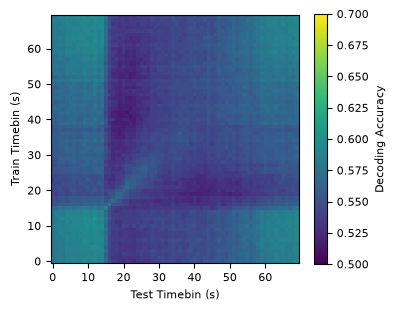

In [50]:
#plot heatmap
fig,ax = plt.subplots(figsize=(4,3.25))
im = ax.imshow(mean_cross_temporal_matrix, aspect='equal', origin='lower', cmap='viridis',vmin=0.5,vmax=0.70,)
        #        extent=[timebins['bin_center'].min()-binsize/2, timebins['bin_center'].max()+binsize/2, 
        #                timebins['bin_center'].min()-binsize/2, timebins['bin_center'].max()+binsize/2])
fig.colorbar(im, ax=ax, label='Decoding Accuracy')
ax.set_xlabel('Test Timebin (s)')
ax.set_ylabel('Train Timebin (s)')


In [48]:
timebins['bin_center'].to_numpy()
# timebins = results.filter(pl.col('is_cross_temporal') == False).select(pl.col('bin_center')).unique()


array([], dtype=float64)

Text(0.5, 1.0, 'Cross-Temporal Slice at -0.15s')

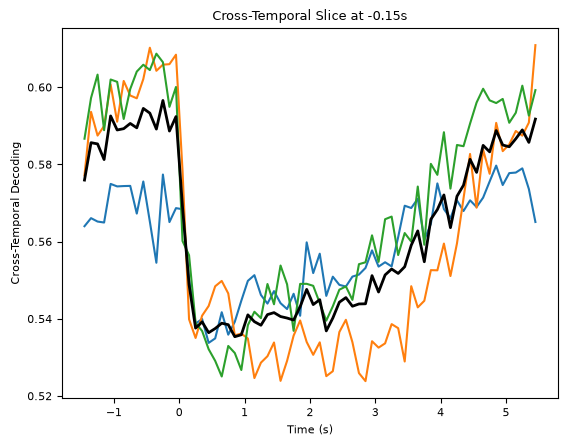

In [66]:
# sel_bin_center = 0.15
sel_bin_center = -0.15
bin_center_ind = np.where(timebins['bin_center'].to_numpy() == sel_bin_center)[0][0]

sel_cross_temporal_slice = np.dstack(cross_temporal_df.query('length>0')['cross_temporal_matrix'].apply(np.vstack).values)[bin_center_ind,:,:].T

fig,ax=plt.subplots(1,1)
ax.plot(timebins['bin_center'].to_numpy(), sel_cross_temporal_slice.T)
ax.plot(timebins['bin_center'].to_numpy(), np.nanmean(sel_cross_temporal_slice, axis=0), 'k', linewidth=2)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Cross-Temporal Decoding')
ax.set_title(f'Cross-Temporal Slice at {sel_bin_center}s')

In [63]:
# cross_temporal_df
# sel_cross_temporal_slice
np.dstack(cross_temporal_df.query('length>0')['cross_temporal_matrix'].apply(np.vstack).values).shape

(70, 70, 3)

array([[0.63978241, 0.67475703, 0.65092319, ..., 0.66000026, 0.65242751,
        0.64236674],
       [0.65549987, 0.6721474 , 0.65443401, ..., 0.67951938, 0.67127502,
        0.67706546],
       [0.81191059, 0.81483588, 0.81805659, ..., 0.79300798, 0.79492349,
        0.79264009],
       ...,
       [0.61270416, 0.60353027, 0.59621312, ..., 0.61518392, 0.63082923,
        0.63422261],
       [0.61738933, 0.59969169, 0.60387911, ..., 0.62430303, 0.63171027,
        0.59075778],
       [0.6583279 , 0.66200572, 0.66317276, ..., 0.67431792, 0.64986554,
        0.66984291]])

In [ ]:
#plot select timepoints

min_timebin=-1.5
max_timebin=0

timebins_array=timebins['bin_center'].to_numpy()

timebin_indices=np.where((timebins_array>=min_timebin) & (timebins_array<=max_timebin))[0]

sel_timebins=timebins_array[timebin_indices]
sub_matrix=mean_cross_temporal_matrix[np.ix_(timebin_indices,timebin_indices)]

fig,ax = plt.subplots(figsize=(4,3.25))
im = ax.imshow(sub_matrix, aspect='equal', origin='lower', vmin=0.5, vmax = 0.75,
               extent=[sel_timebins[0]-binsize/2, sel_timebins[-1]+binsize/2, 
                       sel_timebins[0]-binsize/2, sel_timebins[-1]+binsize/2])
ax.vlines([-1,-0.5], ymin=-1.5, ymax=0,color='k', linewidth=0.5)
ax.hlines([-1,-0.5], xmin=-1.5, xmax=0,color='k', linewidth=0.5)
fig.colorbar(im, ax=ax, label='Decoder Accuracy')
ax.set_xlabel('Test Timebin (s)')
ax.set_ylabel('Train Timebin (s)')
ax.set_xticks([-1.5, -1, -0.5, 0])
ax.set_yticks([-1.5, -1, -0.5, 0])